In [ ]:
#import libraries
import matplotlib.pyplot as pld
import pandas as pd
#reading data
usd_inr_df = pd.read_csv("/content/usd_inr_rate_edited.csv")
crude_df = pd.read_csv("/content/brent_crude_edited.csv")
gold_df = pd.read_csv("/content/gold_price_edited.csv")



In [ ]:
#convert date column to datetime
usd_inr_df['date'] = pd.to_datetime(usd_inr_df['date'], dayfirst=True)
crude_df['date']   = pd.to_datetime(crude_df['date'], dayfirst=True)
gold_df['date']    = pd.to_datetime(gold_df['date'], dayfirst=True)


/tmp/ipython-input-400386639.py:2: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  usd_inr_df['date'] = pd.to_datetime(usd_inr_df['date'], dayfirst=True)
/tmp/ipython-input-400386639.py:3: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  crude_df['date']   = pd.to_datetime(crude_df['date'], dayfirst=True)
/tmp/ipython-input-400386639.py:4: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  gold_df['date']    = pd.to_datetime(gold_df['date'], dayfirst=True)


In [ ]:
#) Sort by date
usd_inr_df = usd_inr_df.sort_values("date")
crude_df   = crude_df.sort_values("date")
gold_df    = gold_df.sort_values("date")



In [ ]:
#Rename “close” to identify the dataset
usd_inr_df = usd_inr_df.rename(columns={"close": "usd_inr"})
crude_df = crude_df.rename(columns={"close": "crude_oil"})
gold_df = gold_df.rename(columns={"close": "gold_price"})


In [ ]:
#data acquisation
#merge the Datasets on the “date” Column
merged = usd_inr_df.merge(crude_df, on='date', how='inner') \
                   .merge(gold_df, on='date', how='inner')


In [ ]:
#data preprocessing
#handle missing values
num=merged.isnull().sum()
print(num)
merged = merged.fillna(method='ffill')
print(merged.head())

date          0
usd_inr       0
crude_oil     0
gold_price    0
dtype: int64
        date    usd_inr  crude_oil   gold_price
0 2021-02-19  72.605400  62.910000  1775.800049
1 2021-02-22  72.553001  65.239998  1806.699951
2 2021-02-23  72.444000  65.370003  1804.400024
3 2021-02-24  72.376999  67.040001  1796.400024
4 2021-02-25  72.400002  66.879997  1774.400024


/tmp/ipython-input-1107308638.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged = merged.fillna(method='ffill')


In [ ]:
#feature engineering
#Create the Target Variable (Future USD–INR)
#to predict next day USD–INR.
merged['target'] = merged['usd_inr'].shift(-1)
merged = merged.dropna()
print(merged)


           date    usd_inr  crude_oil   gold_price     target
0    2021-02-19  72.605400  62.910000  1775.800049  72.553001
1    2021-02-22  72.553001  65.239998  1806.699951  72.444000
2    2021-02-23  72.444000  65.370003  1804.400024  72.376999
3    2021-02-24  72.376999  67.040001  1796.400024  72.400002
4    2021-02-25  72.400002  66.879997  1774.400024  73.150902
...         ...        ...        ...          ...        ...
1250 2026-02-10  90.822800  68.800003  5003.799805  90.587898
1251 2026-02-11  90.587898  69.400002  5071.600098  90.735703
1252 2026-02-12  90.735703  67.519997  4923.700195  90.564102
1253 2026-02-13  90.564102  67.750000  5022.000000  90.782997
1254 2026-02-17  90.782997  67.419998  4882.899902  90.661003

[1255 rows x 5 columns]


In [ ]:
#Feature selection
#x=features
#y=target
X = merged[['usd_inr', 'crude_oil', 'gold_price']]
y = merged['target']
print(X)
print(y)


        usd_inr  crude_oil   gold_price
0     72.605400  62.910000  1775.800049
1     72.553001  65.239998  1806.699951
2     72.444000  65.370003  1804.400024
3     72.376999  67.040001  1796.400024
4     72.400002  66.879997  1774.400024
...         ...        ...          ...
1250  90.822800  68.800003  5003.799805
1251  90.587898  69.400002  5071.600098
1252  90.735703  67.519997  4923.700195
1253  90.564102  67.750000  5022.000000
1254  90.782997  67.419998  4882.899902

[1255 rows x 3 columns]
0       72.553001
1       72.444000
2       72.376999
3       72.400002
4       73.150902
          ...    
1250    90.587898
1251    90.735703
1252    90.564102
1253    90.782997
1254    90.661003
Name: target, Length: 1255, dtype: float64


In [ ]:
#Train–Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


In [ ]:
#. Apply Feature Scaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
#Learn min/max from training data and scale it
X_train_scaled = scaler.fit_transform(X_train)#fit(min,max) + transform
X_test_scaled = scaler.transform(X_test)#Scale test data using training min/max


In [ ]:
#Linear Regression
from sklearn.linear_model import LinearRegression
model = LinearRegression()#Creates a linear regression model
model.fit(X_train_scaled, y_train)#Model learns the relationship between features and target




LinearRegression()

In [ ]:
# Evaluate Your Model Using MAE, MSE, RMSE, and R² Score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = model.predict(X_test_scaled)

# Metrics
mse = mean_squared_error(y_test, y_pred)     # Mean Squared Error
mae = mean_absolute_error(y_test, y_pred)    # Mean Absolute Error
rmse = mse ** 0.5                            # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)                # R² Score

# Print results
print("Model Evaluation Metrics:")
print(f"MAE   : {mae:.4f}")
print(f"MSE   : {mse:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"R² Score : {r2:.4f}")


Model Evaluation Metrics:
MAE   : 0.2023
MSE   : 0.0807
RMSE  : 0.2841
R² Score : 0.9766


In [ ]:
# Random Forest Regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Model training
model = RandomForestRegressor()   # default parameters
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# Evaluation Metrics
mse = mean_squared_error(y_test, y_pred)     # Mean Squared Error
mae = mean_absolute_error(y_test, y_pred)    # Mean Absolute Error
rmse = mse ** 0.5                            # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)                # R² Score

# Print results
print("Random Forest Model Evaluation Metrics:")
print(f"MAE      : {mae:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"R² Score : {r2:.4f}")


Random Forest Model Evaluation Metrics:
MAE      : 1.0456
MSE      : 2.3267
RMSE     : 1.5254
R² Score : 0.3260


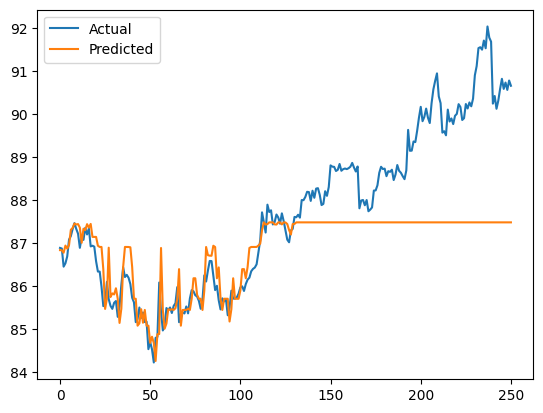

In [ ]:
#plot actual vs predicted of random forest
import matplotlib.pyplot as plt
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.show()


In [ ]:
#make future predictions
latest = merged[['usd_inr','crude_oil','gold_price']].iloc[-1:].copy()
latest_scaled = scaler.transform(latest)
future_pred = model.predict(latest_scaled)


In [ ]:
# Take last row as DataFrame (keeps column names)
latest = merged[['usd_inr','crude_oil','gold_price']].iloc[-1:].copy()

# Scale it
latest_scaled = scaler.transform(latest)

# Predict future USDINR
future_pred = model.predict(latest_scaled)

print("Tomorrow's USD-INR predicted rate:", future_pred[0])


Tomorrow's USD-INR predicted rate: 87.48182655334473


In [ ]:
#Predict for the next day
next_day_pred = model.predict(X_test.iloc[-1:])[0]
print("Next Day Prediction:", next_day_pred)


Next Day Prediction: 87.0881901550293


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


In [ ]:
#Append the first predicted value
import pandas as pd

# Suppose "future_pred" is your predicted next-day USD-INR value
# Example: future_pred = 83.27

predicted_value = future_pred[0]

# Create the next date (assuming daily data)
next_date = merged['date'].iloc[-1] + pd.Timedelta(days=1)

# Build the new row (crude_oil and gold_price must remain same or be predicted)
new_row = {
    'date': next_date,
    'usd_inr': predicted_value,          # predicted USD-INR
    'crude_oil': merged['crude_oil'].iloc[-1],   # keep last known
    'gold_price': merged['gold_price'].iloc[-1], # keep last known
}

# Append to merged dataframe
merged = merged._append(new_row, ignore_index=True)


In [ ]:
#Predict the next day again using the newly added row
# Prepare the input for the new prediction
latest_features = merged[['usd_inr', 'crude_oil', 'gold_price']].iloc[-1]
latest_scaled = scaler.transform([latest_features])

# Predict the next day (2nd day ahead)
next_prediction = model.predict(latest_scaled)
print("Second day prediction =", next_prediction[0])


Second day prediction = 87.43125740051269


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [ ]:
#Append second prediction (optional)
predicted_value_2 = next_prediction[0]

next_date_2 = merged['date'].iloc[-1] + pd.Timedelta(days=1)

new_row_2 = {
    'date': next_date_2,
    'usd_inr': predicted_value_2,
    'crude_oil': merged['crude_oil'].iloc[-1],
    'gold_price': merged['gold_price'].iloc[-1],
}

merged = merged._append(new_row_2, ignore_index=True)
print(merged)


           date    usd_inr  crude_oil   gold_price     target
0    2021-02-19  72.605400  62.910000  1775.800049  72.553001
1    2021-02-22  72.553001  65.239998  1806.699951  72.444000
2    2021-02-23  72.444000  65.370003  1804.400024  72.376999
3    2021-02-24  72.376999  67.040001  1796.400024  72.400002
4    2021-02-25  72.400002  66.879997  1774.400024  73.150902
...         ...        ...        ...          ...        ...
1252 2026-02-12  90.735703  67.519997  4923.700195  90.564102
1253 2026-02-13  90.564102  67.750000  5022.000000  90.782997
1254 2026-02-17  90.782997  67.419998  4882.899902  90.661003
1255 2026-02-18  87.481827  67.419998  4882.899902        NaN
1256 2026-02-19  87.431257  67.419998  4882.899902        NaN

[1257 rows x 5 columns]


In [ ]:
#TO PREDICT MULTIPLE FUTURE DAYS AUTOMATICALLY
def predict_future_days(merged, days):
    df = merged.copy()

    for i in range(days):
        last_row = df[['usd_inr', 'crude_oil', 'gold_price']].iloc[-1]
        last_scaled = scaler.transform([last_row])
        pred = model.predict(last_scaled)[0]

        next_date = df['date'].iloc[-1] + pd.Timedelta(days=1)

        new_row = {
            'date': next_date,
            'usd_inr': pred,
            'crude_oil': df['crude_oil'].iloc[-1],
            'gold_price': df['gold_price'].iloc[-1],
        }

        df = df._append(new_row, ignore_index=True)

    return df

future_df = predict_future_days(merged, 1)  # predict next 10 days
print(future_df)


           date    usd_inr  crude_oil   gold_price     target
0    2021-02-19  72.605400  62.910000  1775.800049  72.553001
1    2021-02-22  72.553001  65.239998  1806.699951  72.444000
2    2021-02-23  72.444000  65.370003  1804.400024  72.376999
3    2021-02-24  72.376999  67.040001  1796.400024  72.400002
4    2021-02-25  72.400002  66.879997  1774.400024  73.150902
...         ...        ...        ...          ...        ...
1253 2026-02-13  90.564102  67.750000  5022.000000  90.782997
1254 2026-02-17  90.782997  67.419998  4882.899902  90.661003
1255 2026-02-18  87.481827  67.419998  4882.899902        NaN
1256 2026-02-19  87.431257  67.419998  4882.899902        NaN
1257 2026-02-20  87.434266  67.419998  4882.899902        NaN

[1258 rows x 5 columns]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
